In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/energy_consumption_large_dataset.csv')

In [ ]:
df

,timestamp,temperature,hour,occupants,past_usage,energy_usage
0,2022-01-01 00:00:00,38.421431,0,2,50.606461,30.797203
1,2022-01-01 01:00:00,18.666063,1,38,30.797203,48.662622
2,2022-01-01 02:00:00,19.134934,2,47,48.662622,54.423722
3,2022-01-01 03:00:00,31.419153,3,28,54.423722,41.860677
4,2022-01-01 04:00:00,28.467676,4,14,41.860677,26.532783
...,...,...,...,...,...,...
99995,2033-05-29 11:00:00,28.431350,11,5,37.366808,38.378263
99996,2033-05-29 12:00:00,19.136954,12,38,38.378263,52.835424
99997,2033-05-29 13:00:00,25.854635,13,27,52.835424,49.680011
99998,2033-05-29 14:00:00,30.403675,14,11,49.680011,43.957810


In [ ]:
df.isnull().sum()

,0
timestamp,0
temperature,0
hour,0
occupants,0
past_usage,0
energy_usage,0


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
X = df[['temperature', 'hour', 'past_usage', 'occupants']]
y = df['energy_usage']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model = MLPRegressor(hidden_layer_sizes=(64, 32),activation='relu',solver='adam',max_iter=500,random_state=42)

In [ ]:
model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.017923404290113
RMSE: 5.037377076187324
R2 Score: 0.8921163515661249


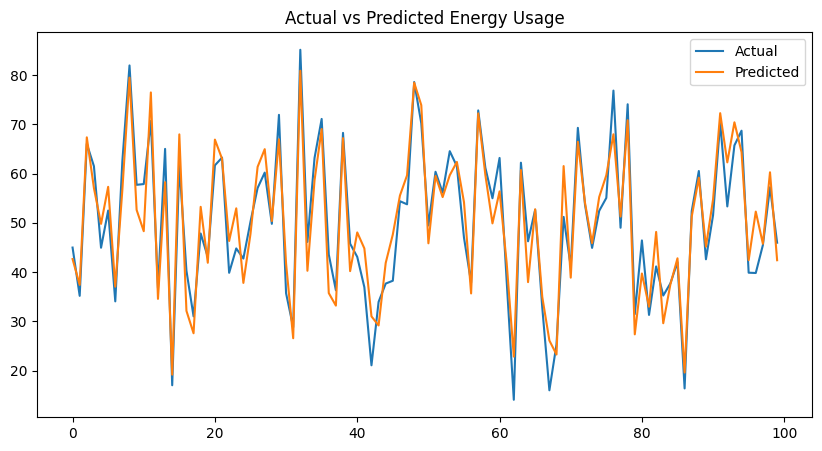

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Energy Usage")
plt.show()

In [ ]:
temperature = float(input("Enter temperature (°C): "))
hour = int(input("Enter hour of day (0-23): "))
past_usage = float(input("Enter past electricity usage: "))
occupants = int(input("Enter number of occupants: "))


user_input = [[temperature, hour, past_usage, occupants]]


user_input_scaled = scaler.transform(user_input)


prediction = model.predict(user_input_scaled)

print("\nPredicted Electricity Usage:", prediction[0])

Enter temperature (°C): 30
Enter hour of day (0-23): 20
Enter past electricity usage: 400
Enter number of occupants: 17

Predicted Electricity Usage: 100.7933341436987


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
